2.
- Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Iniciant des de la ciutat: Alicante


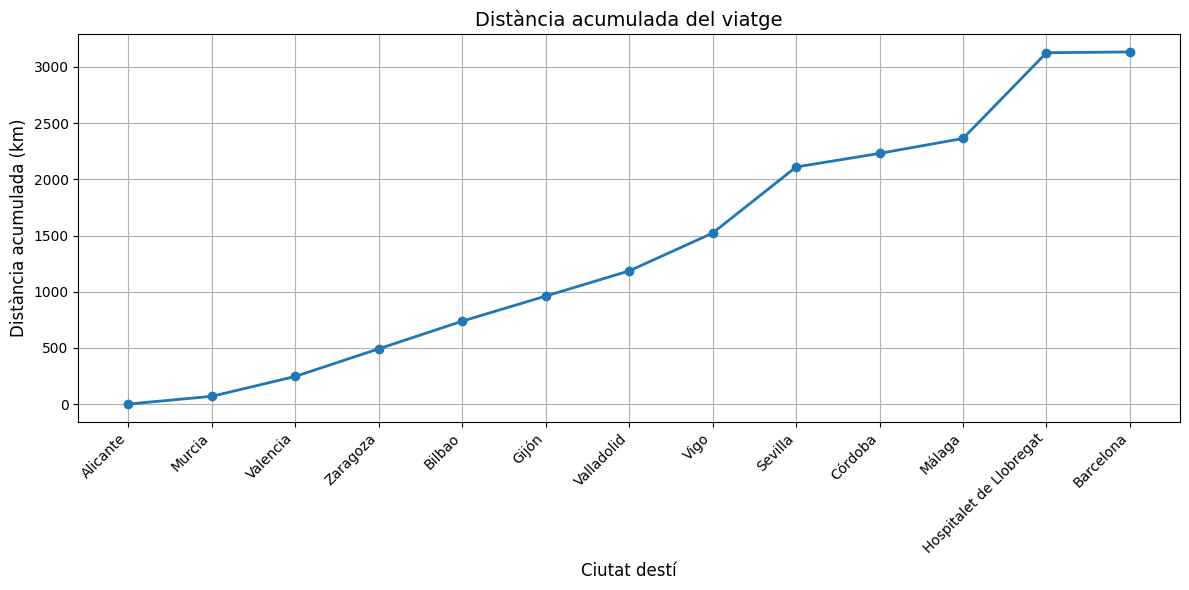

,Ciutat origen,Ciutat destí,distancia,Distància acumulada
0,Alicante,Murcia,69.0,69.0
1,Murcia,Valencia,177.0,246.0
2,Valencia,Zaragoza,246.0,492.0
3,Zaragoza,Bilbao,246.0,738.0
4,Bilbao,Gijón,223.0,961.0
5,Gijón,Valladolid,224.0,1185.0
6,Valladolid,Vigo,337.0,1522.0
7,Vigo,Sevilla,588.0,2110.0
8,Sevilla,Córdoba,121.0,2231.0
9,Córdoba,Málaga,133.0,2364.0


In [6]:
import pandas as pd

# Llegim la matriu de distàncies i eliminem ciutats no desitjades (si existeixen)
df = pd.read_excel('C:\\LLUIS\\Dropbox\\IT ACADEMY\\Sprint 10\\matriu_distancies.xlsx', index_col=0)
df = df.drop(index=['Las Palmas de Gran Canaria', 'Palma'], errors='ignore')
df = df.drop(columns=['Las Palmas de Gran Canaria', 'Palma'], errors='ignore')

def ciutat_mes_propera(df, ciutat):
    # Assumeix que df ja té els noms de ciutats com a índex i com a columnes
    # Comprovem que la ciutat existeixi
    if ciutat not in df.index:
        raise ValueError(f"La ciutat '{ciutat}' no es troba a la taula.")
    
    # Extreiem la fila corresponent
    fila = df.loc[ciutat].copy()
    
    # Eliminem valors NaN i la pròpia ciutat (si hi és)
    fila = fila.dropna()
    
    if ciutat in fila.index:
        fila = fila.drop(ciutat)
    
    if fila.empty:
        raise ValueError(f"No hi ha destinacions vàlides per la ciutat '{ciutat}'.")
    
    # Busquem el valor mínim
    ciutat_mes_propera = fila.idxmin()
    distancia_minima = fila.min()
    
    return ciutat_mes_propera, distancia_minima

def calcular_ruta(df, origen):

    for i in enumerate(df.index):
        
        # inicialitzar entrada
        viatges[i] = {'Ciutat origen': '', 'Ciutat destí': '', 'distancia': 0}
        fila = df.loc[origen].copy()
        
        # eliminar la ciutat mateixa i valors NaN
        if origen in fila.index:
            fila = fila.drop(origen)
        fila = fila.dropna()
        if fila.empty:
            # no hi ha destinacions vàlides
            continue

        # trobar la ciutat més propera i la distància mínima
        destinatari , distancia_min = ciutat_mes_propera(df, origen)
        
        # emmagatzemar el resultat
        viatges[i]['Ciutat origen'] = origen
        viatges[i]['Ciutat destí'] = destinatari
        viatges[i]['distancia'] = float(distancia_min)

        # eliminar la ciutat origen per a la següent iteració
        df = df.drop(index=origen, errors='ignore')
        df = df.drop(columns=origen, errors='ignore')

        # Actualitzar la ciutat origen per al següent iteració
        origen = destinatari
        
def mostrar_grafic(result_df,origen_df):
    import matplotlib.pyplot as plt
    
    # Concatenar la fila origen al DataFrame existent
    result_df = pd.concat([origen_df, result_df], ignore_index=True)
    
    # Recalcular la distància acumulada
    result_df['Distància acumulada'] = result_df['distancia'].cumsum()

    # --- GRÀFIC ---
    plt.figure(figsize=(12, 6))
    plt.plot(result_df['Ciutat destí'], result_df['Distància acumulada'], marker='o', linestyle='-', linewidth=2)

    plt.title('Distància acumulada del viatge', fontsize=14)
    plt.xlabel('Ciutat destí', fontsize=12)
    plt.ylabel('Distància acumulada (km)', fontsize=12)
    # Ajustar la mida de les etiquetes de l’eix X
    plt.xticks(rotation=45, fontsize=10, ha='right')  # 'ha' = alineació horitzontal
    # Opcional: també ajustar l’eix Y
    plt.yticks(fontsize=10)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Per a cada ciutat origen trobem la ciutat destí amb la distància mínima (excloent la mateixa ciutat i NaN)
viatges = {}
origen=input('Ciutat d\'origen (per exemple, Barcelona): ')
try:
    origen = origen.strip()
    if origen not in df.index:
        print(f"La ciutat '{origen}' no es troba a la taula.")
        
    else:
        # Afegir manualment la primera ciutat amb distància 0 pel grafic
        origen_df = pd.DataFrame({
            'Ciutat origen': [origen],        
            'Ciutat destí': [origen],   # pots posar None o la ciutat d'on  partim
            'distancia': [0]
        })
        
        print(f"Iniciant des de la ciutat: {origen}")
        calcular_ruta(df, origen)
        # Convertim el resultat a DataFrame per a una visualització més neta
        result_df = pd.DataFrame.from_dict(viatges, orient='index', columns=['Ciutat origen', 'Ciutat destí', 'distancia'])
        result_df.reset_index(drop=True, inplace=True)
        # Afegim la distància acumulada
        result_df['Distància acumulada'] = result_df['distancia'].cumsum()                     
        mostrar_grafic(result_df.head(12),origen_df)  
except:
    pass

result_df.head(12)

    
